In [149]:
import numpy as np
import pandas as pd

df=pd.read_csv('/home/karan/DL2.0/Datasets/Churn_Modelling.csv')
print(df.shape)
df.head()

(10000, 14)


,RowNumber,CustomerId,Surname,CreditScore,Geography,Gender,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Exited
0,1,15634602,Hargrave,619,France,Female,42,2,0.00,1,1,1,101348.88,1
1,2,15647311,Hill,608,Spain,Female,41,1,83807.86,1,0,1,112542.58,0
2,3,15619304,Onio,502,France,Female,42,8,159660.80,3,1,0,113931.57,1
3,4,15701354,Boni,699,France,Female,39,1,0.00,2,0,0,93826.63,0
4,5,15737888,Mitchell,850,Spain,Female,43,2,125510.82,1,1,1,79084.10,0


In [150]:
df.info()
df.duplicated().sum()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 14 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   RowNumber        10000 non-null  int64  
 1   CustomerId       10000 non-null  int64  
 2   Surname          10000 non-null  object 
 3   CreditScore      10000 non-null  int64  
 4   Geography        10000 non-null  object 
 5   Gender           10000 non-null  object 
 6   Age              10000 non-null  int64  
 7   Tenure           10000 non-null  int64  
 8   Balance          10000 non-null  float64
 9   NumOfProducts    10000 non-null  int64  
 10  HasCrCard        10000 non-null  int64  
 11  IsActiveMember   10000 non-null  int64  
 12  EstimatedSalary  10000 non-null  float64
 13  Exited           10000 non-null  int64  
dtypes: float64(2), int64(9), object(3)
memory usage: 1.1+ MB


np.int64(0)

In [151]:
df["Exited"].value_counts()

Exited
0    7963
1    2037
Name: count, dtype: int64

In [152]:
df["Gender"].value_counts()

Gender
Male      5457
Female    4543
Name: count, dtype: int64

In [153]:
df["Geography"].value_counts()

Geography
France     5014
Germany    2509
Spain      2477
Name: count, dtype: int64

In [154]:
df.drop(columns=["RowNumber","CustomerId","Surname"],inplace=True)
df.head()

,CreditScore,Geography,Gender,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Exited
0,619,France,Female,42,2,0.00,1,1,1,101348.88,1
1,608,Spain,Female,41,1,83807.86,1,0,1,112542.58,0
2,502,France,Female,42,8,159660.80,3,1,0,113931.57,1
3,699,France,Female,39,1,0.00,2,0,0,93826.63,0
4,850,Spain,Female,43,2,125510.82,1,1,1,79084.10,0


In [155]:
df=pd.get_dummies(df,columns=["Geography","Gender"],drop_first=True)

In [156]:
from sklearn.model_selection import train_test_split
x=df.drop(columns=["Exited"])
y=df["Exited"]
x_train,x_test,y_train,y_test=train_test_split(x,y,test_size=0.2,random_state=42)


In [157]:
from sklearn.preprocessing import StandardScaler
s=StandardScaler()
x_train=s.fit_transform(x_train)
x_test=s.transform(x_test)


In [ ]:
import tensorflow
from tensorflow import keras
from tensorflow.keras import Sequential
from tensorflow.keras.layers import Dense

model=Sequential()
model.add(Dense(10,activation="sigmoid",input_dim=11))
model.add(Dense(10,activation="sigmoid",input_dim=11))
model.add(Dense(10,activation="sigmoid",input_dim=11))i
model.add(Dense(1,activation="sigmoid",input_dim=11))
model.summary()

model.compile(loss="binary_crossentropy",optimizer="adam",metrics=["accuracy"])
history=model.fit(x_train,y_train,epochs=100,validation_split=0.2)

/home/karan/miniconda3/envs/tf_gpu/lib/python3.10/site-packages/keras/src/layers/core/dense.py:95: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential_13"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_69 (Dense)                │ (None, 10)             │           120 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_70 (Dense)                │ (None, 10)             │           110 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_71 (Dense)                │ (None, 10)             │           110 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_72 (Dense)                │ (None, 1)              │            11 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 351 (1.37 KB)

 Trainable params: 351 (1.37 KB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/100


200/200 ━━━━━━━━━━━━━━━━━━━━ 3s 8ms/step - accuracy: 0.7934 - loss: 0.5110 - val_accuracy: 0.7987 - val_loss: 0.4972
Epoch 2/100
200/200 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - accuracy: 0.7934 - loss: 0.5017 - val_accuracy: 0.7987 - val_loss: 0.4892
Epoch 3/100
200/200 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - accuracy: 0.7934 - loss: 0.4897 - val_accuracy: 0.7987 - val_loss: 0.4707
Epoch 4/100
200/200 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - accuracy: 0.7934 - loss: 0.4687 - val_accuracy: 0.7987 - val_loss: 0.4459
Epoch 5/100
200/200 ━━━━━━━━━━━━━━━━━━━━ 2s 7ms/step - accuracy: 0.7934 - loss: 0.4483 - val_accuracy: 0.8037 - val_loss: 0.4305
Epoch 6/100
200/200 ━━━━━━━━━━━━━━━━━━━━ 4s 21ms/step - accuracy: 0.8022 - loss: 0.4384 - val_accuracy: 0.8163 - val_loss: 0.4234
Epoch 7/100
200/200 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - accuracy: 0.8114 - loss: 0.4339 - val_accuracy: 0.8206 - val_loss: 0.4212
Epoch 8/100
200/200 ━━━━━━━━━━━━━━━━━━━━ 1s 7ms/step - accuracy: 0.8097 - loss: 0.4319 - val_accuracy: 0.822

In [159]:
model.layers[0].get_weights()

[array([[ 0.05427289,  0.23061173,  0.41008988,  0.0743919 ,  0.43439737,
         -0.13856462,  0.2765211 ,  0.1454844 ,  0.09399465,  0.3646148 ],
        [-1.8363464 , -0.02588721,  0.26919279, -1.2455162 , -0.901293  ,
         -0.81658816, -0.21376972, -1.3745155 , -0.51627713, -0.30771366],
        [ 0.05570025, -0.01431472,  0.32539544, -0.152549  ,  0.3571016 ,
         -0.06645261,  0.13111272,  0.06859358,  0.01617139, -0.04036223],
        [ 0.26491016, -0.94239926, -0.09633996, -0.17216253, -0.4219286 ,
          0.15810011,  0.1002507 , -0.5415106 , -0.72939557,  0.2975464 ],
        [ 0.22018659, -0.7688805 , -0.41208026, -0.7061777 ,  0.71809536,
          0.97733545,  0.80104613, -0.6022055 , -2.861747  ,  0.22841729],
        [-0.05526983, -0.13978556,  0.39340353,  0.045979  ,  0.06586452,
          0.07463436,  0.18507528,  0.02308161,  0.01232911, -0.17449431],
        [-0.57856566,  0.76133734,  0.9276054 , -0.50451213,  0.33390263,
          1.2446375 , -1.2321006

In [160]:
y_log=model.predict(x_test)

63/63 ━━━━━━━━━━━━━━━━━━━━ 1s 8ms/step


In [161]:
y_pred=np.where(y_log>0.5,1,0)

In [162]:
from sklearn.metrics import accuracy_score
print(accuracy_score(y_test,y_pred))

0.862


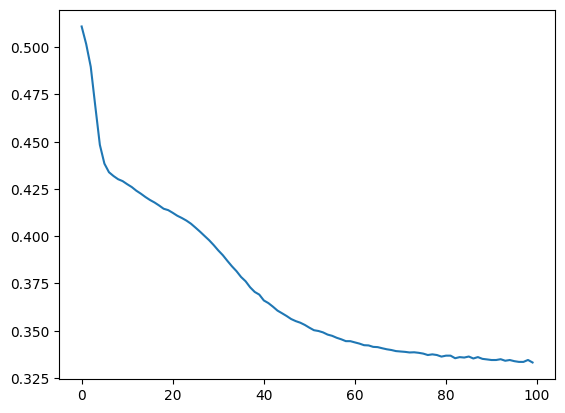

In [163]:
import matplotlib.pyplot as plt
plt.plot(history.history["loss"])

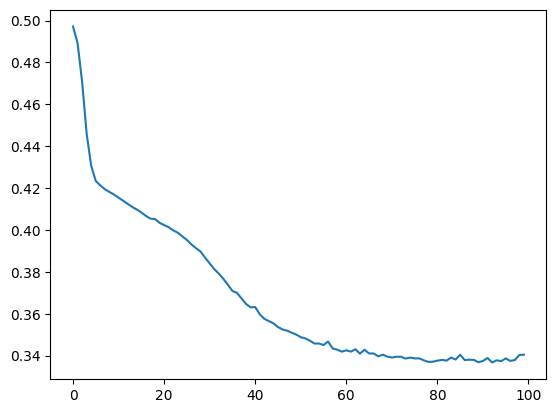

In [164]:
plt.plot(history.history["val_loss"])

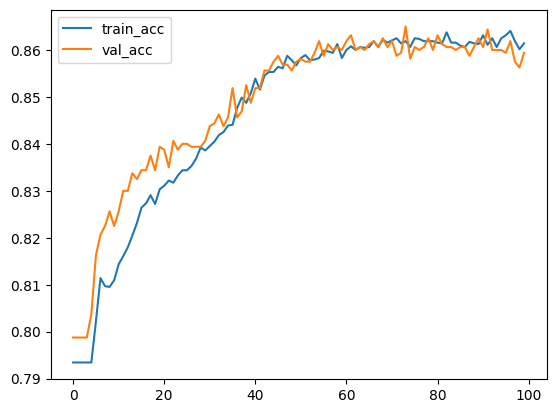

In [165]:
plt.plot(history.history["accuracy"])
plt.plot(history.history["val_accuracy"])
plt.legend(["train_acc","val_acc"])